## Tensors and Operations

In [1]:
import tensorflow as tf

In [ ]:
tf.constant([[1.,2.,3.], [4.,5.,6.]])

<tf.Tensor: shape=(2, 3), dtype=float32, numpy=
array([[1., 2., 3.],
       [4., 5., 6.]], dtype=float32)>

In [3]:
t = tf.constant([[1.,2.,3.], [4.,5.,6.]])
t.shape

TensorShape([2, 3])

In [4]:
t.dtype

tf.float32

In [5]:
t[:, 1:]

<tf.Tensor: shape=(2, 2), dtype=float32, numpy=
array([[2., 3.],
       [5., 6.]], dtype=float32)>

In [6]:
t[..., 1, tf.newaxis]

<tf.Tensor: shape=(2, 1), dtype=float32, numpy=
array([[2.],
       [5.]], dtype=float32)>

In [7]:
t + 10

<tf.Tensor: shape=(2, 3), dtype=float32, numpy=
array([[11., 12., 13.],
       [14., 15., 16.]], dtype=float32)>

In [8]:
tf.square(t)

<tf.Tensor: shape=(2, 3), dtype=float32, numpy=
array([[ 1.,  4.,  9.],
       [16., 25., 36.]], dtype=float32)>

In [9]:
t @ tf.transpose(t)

<tf.Tensor: shape=(2, 2), dtype=float32, numpy=
array([[14., 32.],
       [32., 77.]], dtype=float32)>

keras also has its own low level API -> but it covers only subset of tensorflow

In [2]:
from tensorflow import keras

In [13]:
K = keras.backend
K.square(K.transpose(t)) + 10

<tf.Tensor: shape=(3, 2), dtype=float32, numpy=
array([[11., 26.],
       [14., 35.],
       [19., 46.]], dtype=float32)>

Tensor and numpy can be used together!!

In [15]:
import numpy as np

In [16]:
a = np.array([2., 4., 5.])
tf.constant(a)

<tf.Tensor: shape=(3,), dtype=float64, numpy=array([2., 4., 5.])>

In [17]:
t.numpy()

array([[1., 2., 3.],
       [4., 5., 6.]], dtype=float32)

In [18]:
tf.square(a)

<tf.Tensor: shape=(3,), dtype=float64, numpy=array([ 4., 16., 25.])>

In [19]:
tf.square(t)

<tf.Tensor: shape=(2, 3), dtype=float32, numpy=
array([[ 1.,  4.,  9.],
       [16., 25., 36.]], dtype=float32)>

Notice that numpy use 64 points of floats while tensor uses 32 since 32 is enough for models

In [20]:
tf.constant(2.) + tf.constant(40)

InvalidArgumentError: cannot compute AddV2 as input #1(zero-based) was expected to be a float tensor but is a int32 tensor [Op:AddV2] name: 

In [22]:
tf.constant(2.) + tf.constant(40., dtype=tf.float64)

InvalidArgumentError: cannot compute AddV2 as input #1(zero-based) was expected to be a float tensor but is a double tensor [Op:AddV2] name: 

In [24]:
t2 = tf.constant(40., dtype=tf.float64)
tf.constant(2.0) + tf.cast(t2, tf.float32)

<tf.Tensor: shape=(), dtype=float32, numpy=42.0>

## Variables

In [25]:
v = tf.Variable([[1., 2., 3.], [4., 5., 6.]])
v

<tf.Variable 'Variable:0' shape=(2, 3) dtype=float32, numpy=
array([[1., 2., 3.],
       [4., 5., 6.]], dtype=float32)>

In [26]:
v.assign(2 * v)

<tf.Variable 'UnreadVariable' shape=(2, 3) dtype=float32, numpy=
array([[ 2.,  4.,  6.],
       [ 8., 10., 12.]], dtype=float32)>

In [27]:
v[0, 1].assign(42)

<tf.Variable 'UnreadVariable' shape=(2, 3) dtype=float32, numpy=
array([[ 2., 42.,  6.],
       [ 8., 10., 12.]], dtype=float32)>

In [28]:
v[:, 2].assign([0., 1.])

<tf.Variable 'UnreadVariable' shape=(2, 3) dtype=float32, numpy=
array([[ 2., 42.,  0.],
       [ 8., 10.,  1.]], dtype=float32)>

In [29]:
v.scatter_nd_update(indices=[[0,0],[1,2]], updates=[100., 200.])

<tf.Variable 'UnreadVariable' shape=(2, 3) dtype=float32, numpy=
array([[100.,  42.,   0.],
       [  8.,  10., 200.]], dtype=float32)>

## Other Data Structures

1. Sparse tensors (tf.SparseTensor) -> tensors containing mostly 0s
2. Tensor arrays (tf.TensorArray) -> lists of tensors
3. Ragged tensors (tf.RaggedTensor) -> static lists of tensors which all tensor has same shape and dtype
4. String tensors -> regular tensors of type tf.string
5. Sets -> represented as regular tensors such as tf.constant9[[1, 2], [3, 4]] can be {1, 2} and {3, 4}
6. Queues -> store tensors across multiple steps (many kinds such as FIFO, FIFOQueue, PriorityQueue)

## Customizing Models and Training Algorithms

In case that the data nosiy, we cannot use MSE and MAE since they will penalize outliers. Thus we can use Huber, but it is not part of keras API (but i think in new version, there is avaliable!)

In [30]:
def huber_fn(y_true, y_pred):
    error = y_true - y_pred
    is_small_error = tf.abs(error) < 1
    squared_loss = tf.square(error) / 2
    linear_loss = tf.abs(error) - 0.5
    return tf.where(is_small_error, squared_loss, linear_loss)

Now we can this customized loss in model!!

In [33]:
model.compile(loss=huber_fn, optimizer="nadam")
model.fit(X_train, y_train, [...])

NameError: name 'model' is not defined

## Saving and Loading Models That Contain Custom Components

In [ ]:
model = keras.models.load_model("my_model_with_a_custom_loss.h5",
                                custom_objects={"huber_fn": huber_fn})

In [ ]:
def create_huber(threshold=1.0):
    def huber_fn(y_true, y_pred):
        error = y_true - y_pred
        is_small_error = tf.abs(error) < threshold
        squared_loss = tf.square(error) / 2
        linear_loss = tf.abs(error) - 0.5
        return tf.where(is_small_error, squared_loss, linear_loss)
    return huber_fn

model.compile(loss=create_huber(2.0), optimizer="nadam")

In [ ]:
model = keras.models.load_model("my_model_with_a_custom_loss_threshold_2.h5",
                                custom_objects={"huber_fn": huber_fn(2.0)})

In [34]:
class HuberLoss(keras.losses.Loss):
    def __init__(self, threshold=1.0, **kwargs):
        self.threshold = threshold
        super().__init__(**kwargs)
    def call(self, y_true, y_pred):
        error = y_true - y_pred
        is_small_error = tf.abs(error) < self.threshold
        squared_loss = tf.square(error) / 2
        linear_loss = tf.abs(error) - 0.5
        return tf.where(is_small_error, squared_loss, linear_loss)
    def get_config(self):
        base_config = super().get_config()
        return {**base_config, "threshold": self.threshold}

In [ ]:
model.compile(loss=HuberLoss(2.), optimizer="nadam")

In [ ]:
model = keras.models.load_model("my_model_with_a_custom_loss_class.h5",
                                custom_objects={"HuberLoss": HuberLoss})

## Customize Activation Functions, Initializers, Regularizers and Constraints

In [3]:
# Example

def mu_softplus(z):
    return tf.math.log(tf.exp(z) + 1.0)

def my_glorot_initializer(shape, dtype=tf.float32):
    std = tf.sqrt(2. / (shape[0] + shape[1]))
    return tf.random.normal(shape, stddev=std, dtype=dtype)

def my_l1_regularizer(weights):
    return tf.reduce_sum(tf.abs(0.01 * weights))

def my_positive_weights(weights):
    return tf.where(weights < 0., tf.zeros_like(weights), weights)

In [4]:
layer = keras.layers.Dense(30, activation=mu_softplus,
                            kernel_initializer=my_glorot_initializer,
                            kernel_regularizer=my_l1_regularizer,
                            kernel_constraint=my_positive_weights)

In [5]:
class MyL1Regularizer(keras.regularizers.Regularizer):
    def __init__(self, factor):
        self.factor = factor
    def __call__(self, weights):
        return tf.reduce_sum(tf.abs(self.factor * weights))
    def get_config(self):
        return {"factor": self.factor}

## Custom Metrics

In [7]:
precision = keras.metrics.Precision()
precision([0, 1, 1, 1, 0, 1, 0, 1], [1, 1, 0, 1, 0, 1, 0, 1])

<tf.Tensor: shape=(), dtype=float32, numpy=0.800000011920929>

In [8]:
precision([0,1,0,0,1,0,1,1], [1,0,1,1,0,0,0,0])

<tf.Tensor: shape=(), dtype=float32, numpy=0.5>

0.5 in the second batch is not the second batch precision, its the latest preicision so far. This is called "streaming metrics"

In [9]:
precision.result()

<tf.Tensor: shape=(), dtype=float32, numpy=0.5>

In [12]:
precision.variables

[<Variable path=precision_1/true_positives, shape=(1,), dtype=float32, value=[4.]>,
 <Variable path=precision_1/false_positives, shape=(1,), dtype=float32, value=[4.]>]

In [13]:
precision.reset_state()

In [14]:
class HuberMetric(keras.metrics.Metric):
    def __init__(self, threshold=1.0, **kwargs):
        super().__init__(**kwargs) # handles base args (such as data type)
        self.threshold = threshold
        self.huber_fn = create_huber(threshold)
        self.total = self.add_weight("total", initializer="zeros")
        self.count = self.add_weight("count", initializer="zeros")
    def update_state(self, y_true, y_pred, sample_weight=None):
        metric = self.huber_fn(y_true, y_pred)
        self.total.assign_add(tf.reduce_sum(metric))
        self.count.assign_add(tf.cast(tf.size(y_true), tf.float32))
    def result(self):
        return self.total / self.count
    def get_config(self):
        base_config = super().get_config()
        return {**base_config, "threshold": self.threshold}

## Custom Layers

U can customize the layers such as when the layers are repetitives or identical like A B C A B C A B C, we can create D layer so it can be D D D instead

In [15]:
# for some layers with no weight config -> use lambda layers
exponential_layer = keras.layers.Lambda(lambda x: tf.exp(x))

In [16]:
class MyDense(keras.layers.Layer):
    def __init__(self, units, activition=None, **kwargs):
        super().__init__(**kwargs)
        self.units=units
        self.activition = keras.activations.get(activition)
    
    def build(self, batch_input_shape):
        self.kenel = self.add_weight(
            name="kernel", shape=[batch_input_shape[-1], self.units],
            initializer="glorot_normal")
        self.bias = self.add_weight(
            name="bias", shape=[self.units], initializer="zeros")
        super().build(batch_input_shape) # must be at the end
    
    def call(self, X):
        return self.activition(X @ self.kernel + self.bias)
    
    def compute_output_shape(self, batch_input_shape):
        return tf.TensorShape(batch_input_shape.as_list()[:-1] + [self.units])
    
    def get_config(self):
        base_config = super().get_config()
        return {**base_config, "units": self.units,
                "activation": keras.activations.serialize(self.activition)}

- To create a layer with multiple inputs (concatenate), call() method should be a tuple containing all the inputs
- To create a layer with multiple output, call() method should return the list of outputs

In [17]:
# Example
class MyMultiLayer(keras.layers.Layer):
    def call(self, X):
        X1, X2 = X
        return [X1 + X2, X1 * X2, X1 / X2]
    
    def compute_output_shape(self, batch_input_shape):
        b1, b2 = batch_input_shape
        return [b1,b1,b1]

if u want a different behavior such as Dropout or BatchNormalization layers then must add training argument to the call() method

In [ ]:
# Example -> add gaussian noise

class MyGaussianNoise(keras.layers.Layer):
    def __init__(self, stddev, **kwargs):
        super().__init__(**kwargs)
        self.stddev = stddev
    
    def call(self, X, training=None):
        if training:
            noise = tf.random.normal(tf.shape(X), stddev=self.stddev)
            return X + noise
        else:
            return X
    
    def compute_output_shape(self, batch_input_shape):
        return batch_input_shape

## Custom Model

Example Customized Model

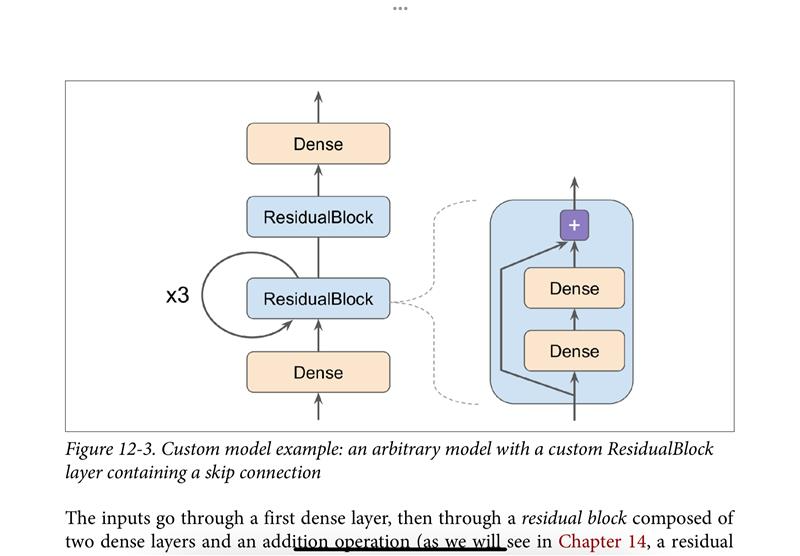

In [18]:
# Lets start with the identical residual block

class ResidualBlock(keras.layers.Layer):
    def __init__(self, n_layers, n_neurons, **kwargs):
        super().__init__(**kwargs)
        self.hidden = [keras.layers.Dense(n_neurons, activation="elu",
                                            kernel_initializer="he_normal")
                        for _ in range(n_layers)]
    
    def call(self, inputs):
        Z = inputs
        for layer in self.hidden:
            Z = layer(Z)
        return inputs + Z

In [19]:
class ResidualRegressor(keras.Model):
    def __init__(self, output_dim, **kwargs):
        super().__init__(**kwargs)
        self.hidden1 = keras.layers.Dense(30, activation="elu",
                                            kernel_initializer="he_normal")
        self.block1 = ResidualBlock(2 , 30)
        self.block2 = ResidualBlock(2 , 30)
        self.out = keras.layers.Dense(output_dim)

    def call(self, inputs):
        Z = self.hidden1(inputs)
        for _ in range(1 + 3):
            Z = self.block1(Z)
        Z = self.block2(Z)
        return self.out(Z)


## Losses and Metrics Based on Model Internals

In [ ]:
class ReconstructingRegressor(keras.Model):
    def __init__(self, output_dim, **kwargs):
        super().__init__(*kwargs)
        self.hidden = [keras.layers.Dense(30, activation="selu",
                                            kernel_initializer="lecun_normal")
                        for _ in range(5)]
        self.out = keras.layers.Dense(output_dim)
    
    def build(self, batch_input_shape):
        n_inputs = batch_input_shape[-1]
        self.reconstruct = keras.layers.Dense(n_inputs)
        super().build(batch_input_shape)
    
    def call(self, inputs):
        Z = inputs
        for layer in self.hidden:
            Z = layer(Z)
        reconstruction = self.reconstruct(Z)
        recon_loss = tf.reduce_mean(tf.square(reconstruction - inputs))
        self.add_loss(0.05 * recon_loss)
        return self.out(Z)

## Computing Gradients Using Autodiff

In [20]:
def f(w1, w2):
    return 3 * w1 ** 2 + 2 * w1 * w2

In [21]:
w1, w2 = 5, 3
eps = 1e-6
(f(w1 + eps, w2) - f(w1, w2)) / eps

36.000003007075065

In [23]:
(f(w1, w2 + eps) - f(w1, w2)) / eps

10.000000003174137

In [32]:
w1, w2 = tf.Variable(5.) , tf.Variable(3.)
with tf.GradientTape() as tape:
    z = f(w1, w2)

gradients = tape.gradient(z, [w1, w2])

In [33]:
gradients

[<tf.Tensor: shape=(), dtype=float32, numpy=36.0>,
 <tf.Tensor: shape=(), dtype=float32, numpy=10.0>]

In [28]:
with tf.GradientTape() as tape:
    z = f(w1, w2)

dz_dw1 = tape.gradient(z, w1) # => 36.0
dz_dw2 = tape.gradient(z, w2) # => ERROR!!!!

RuntimeError: A non-persistent GradientTape can only be used to compute one set of gradients (or jacobians)

In [29]:
with tf.GradientTape(persistent=True) as tape:
    z = f(w1, w2)

dz_dw1 = tape.gradient(z, w1) # => 36.0
dz_dw2 = tape.gradient(z, w2) # => ERROR!!!!
del tape

In [30]:
c1, c2 = tf.Variable(5.) , tf.Variable(3.)
with tf.GradientTape() as tape:
    z = f(c1, c2)

gradients = tape.gradient(z, [c1, c2])

In [31]:
gradients

[<tf.Tensor: shape=(), dtype=float32, numpy=36.0>,
 <tf.Tensor: shape=(), dtype=float32, numpy=10.0>]

## Custom Training Loops

In [34]:
l2_reg = keras.regularizers.l2(0.05)
model = keras.models.Sequential([
    keras.layers.Dense(30, activation="elu", kernel_initializer="he_normal", 
                        kernel_regularizer=l2_reg),
    keras.layers.Dense(1, kernel_regularizer=l2_reg)                    
])

In [35]:
def random_batch(iteration, total, loss, metrics=None):
    metrics = " - ".join(["{}: {:.4}".format(m.name,m,result())])

    end = "" if iteration < total else "\n"
    print("\r{}/{} - ".format(iteration, total) + metrics, end=end)

In [36]:
n_epochs = 5
batch_size = 32
n_steps = len(X_train) // batch_size
optimizer = keras.optimizers.Nadam(lr=0.01)
loss_fn = keras.losses.mean_squared_error
mean_loss = keras.metrics.Mean()
metrics = [keras.metrics.MeanAbsoluteError()]

NameError: name 'X_train' is not defined

In [37]:
for epoch in range(1, n_epochs + 1):
    print("Epoch {}/{}".format(epoch, n_epochs))
    for step in range(1, n_steps + 1):
        X_batch, y_batch = random_batch(X_train_scaled, y_train)
        with tf.GradientTape() as tape:
            y_pred = model(X_batch, training=True)
            main_loss = tf.reduce_mean(loss_fn(y_batch, y_pred))
            loss = tf.add_n([main_loss] + model.losses)
        gradients = tape.gradient(loss, model.trainable_variables)
        optimizer.apply_gradients(zip(gradients, model.trainable_variables))
        mean_loss(loss)
        for metric in metrics:
            metric(y_batch, y_pred)
        print_status_bar(len(y_train), len(y_train), mean_loss, metrics)
        for metric in [mean_loss] + metrics:
            metric.reset_states()

Epoch 1/5


NameError: name 'n_steps' is not defined

## TensorFlow Functions and Graphs

In [38]:
def cube(x):
    return x ** 3

In [39]:
cube(2)

8

In [40]:
cube(tf.constant(2.0))

<tf.Tensor: shape=(), dtype=float32, numpy=8.0>

In [41]:
tf_cube = tf.function(cube)
tf_cube

In [42]:
tf_cube(2)

<tf.Tensor: shape=(), dtype=int32, numpy=8>

In [43]:
tf_cube(tf.constant(2.0))

<tf.Tensor: shape=(), dtype=float32, numpy=8.0>

In [44]:
@tf.function
def tf_cube(x):
    return x ** 3

In [45]:
tf_cube.python_function(2)

8